In [ ]:
!pip install -q sentence-transformers gradio datasets scikit-learn pandas numpy matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import gradio as gr

import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

print("✅ Semantic AI model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Semantic AI model loaded successfully!


In [ ]:
from datasets import load_dataset

print("📥 Loading Quora Question Pairs dataset...")

dataset = load_dataset(
    "sentence-transformers/quora-duplicates",
    "pair"
)

print("✅ Dataset loaded successfully!")
print(dataset)

📥 Loading Quora Question Pairs dataset...


pair/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 10.7MB            

pair/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/149263 [00:00<?, ? examples/s]

✅ Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['anchor', 'positive'],
        num_rows: 149263
    })
})


In [ ]:
# Convert the dataset to a pandas DataFrame
df = dataset["train"].to_pandas()

print("✅ Dataset converted to DataFrame")
print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

✅ Dataset converted to DataFrame

Shape: (149263, 2)

Columns:
['anchor', 'positive']

First 5 rows:


,anchor,positive
0,Astrology: I am a Capricorn Sun Cap moon and c...,"I'm a triple Capricorn (Sun, Moon and ascendan..."
1,How can I be a good geologist?,What should I do to be a great geologist?
2,How do I read and find my YouTube comments?,How can I see all my Youtube comments?
3,What can make Physics easy to learn?,How can you make physics easy to learn?
4,What was your first sexual experience like?,What was your first sexual experience?


In [ ]:
# ============================================
# STEP 6: Create Positive and Negative Pairs
# ============================================

import random

# Make the result reproducible
random.seed(42)
np.random.seed(42)

# Number of positive pairs we want
N = 5000

# Take 5000 known positive pairs
positive_pairs = df.sample(
    n=N,
    random_state=42
).copy()

positive_pairs = positive_pairs.rename(
    columns={
        "anchor": "question1",
        "positive": "question2"
    }
)

positive_pairs["label"] = 1


# --------------------------------------------
# Create negative pairs
# --------------------------------------------

# Shuffle question2 independently.
# This breaks the original semantic relationship.
shuffled_questions = (
    positive_pairs["question2"]
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

negative_pairs = positive_pairs[
    ["question1"]
].reset_index(drop=True)

negative_pairs["question2"] = shuffled_questions

negative_pairs["label"] = 0


# --------------------------------------------
# Combine positive + negative pairs
# --------------------------------------------

project_df = pd.concat(
    [positive_pairs, negative_pairs],
    ignore_index=True
)

# Shuffle the complete dataset
project_df = project_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


print("✅ Project dataset created successfully!")

print("\nDataset shape:", project_df.shape)

print("\nLabel distribution:")
print(project_df["label"].value_counts())

print("\nFirst 10 rows:")
display(project_df.head(10))

✅ Project dataset created successfully!

Dataset shape: (10000, 3)

Label distribution:
label
0    5000
1    5000
Name: count, dtype: int64

First 10 rows:


,question1,question2,label
0,What should I do to best utilize a shopify sto...,How can I earn money online?,0
1,Is education a Jewish tradition?,Why is education valued in Jewish culture?,1
2,What is the best website where we can read/dow...,Which is the best website to download books fo...,1
3,"What is the greatest, most beautiful city in t...",What is the most beautiful city in the world?,1
4,How do I stop daydreaming? And concentrate on ...,How do I avoid or stop daydreaming?,1
5,What is the difference between milk allergy an...,How can I overcome porn addiction?,0
6,Music: What's your favourite song at the moment?,What's your favorite song right now?,1
7,How come i get bored so easily?,What is it that we indians are doing collectiv...,0
8,Which is the best smartphone to buy in august ...,What is going to happen to the value of rupee ...,0
9,Which is the best movie of 2016?,What has been the best movie of 2016?,1


In [ ]:
# ============================================
# STEP 7: Clean and Validate Dataset
# ============================================

# Make a copy so our original dataset stays safe
clean_df = project_df.copy()

print("Initial dataset size:", len(clean_df))

# --------------------------------------------
# 1. Remove missing values
# --------------------------------------------

clean_df = clean_df.dropna(
    subset=["question1", "question2"]
)

# --------------------------------------------
# 2. Convert everything to string
# --------------------------------------------

clean_df["question1"] = clean_df["question1"].astype(str)
clean_df["question2"] = clean_df["question2"].astype(str)

# --------------------------------------------
# 3. Remove unnecessary whitespace
# --------------------------------------------

clean_df["question1"] = (
    clean_df["question1"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

clean_df["question2"] = (
    clean_df["question2"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# --------------------------------------------
# 4. Remove empty questions
# --------------------------------------------

clean_df = clean_df[
    (clean_df["question1"] != "") &
    (clean_df["question2"] != "")
]

# --------------------------------------------
# 5. Remove exact duplicate pairs
# --------------------------------------------

clean_df = clean_df.drop_duplicates(
    subset=["question1", "question2"]
)

# --------------------------------------------
# 6. Remove identical questions
# --------------------------------------------

clean_df = clean_df[
    clean_df["question1"].str.lower()
    != clean_df["question2"].str.lower()
]

# --------------------------------------------
# Reset index
# --------------------------------------------

clean_df = clean_df.reset_index(drop=True)

# --------------------------------------------
# Display results
# --------------------------------------------

print("\n✅ Dataset cleaning completed!")

print("\nFinal dataset size:", len(clean_df))

print("\nLabel distribution:")
print(clean_df["label"].value_counts())

print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nSample cleaned data:")
display(clean_df.head(10))

Initial dataset size: 10000

✅ Dataset cleaning completed!

Final dataset size: 9995

Label distribution:
label
0    5000
1    4995
Name: count, dtype: int64

Missing values:
question1    0
question2    0
label        0
dtype: int64

Sample cleaned data:


,question1,question2,label
0,What should I do to best utilize a shopify sto...,How can I earn money online?,0
1,Is education a Jewish tradition?,Why is education valued in Jewish culture?,1
2,What is the best website where we can read/dow...,Which is the best website to download books fo...,1
3,"What is the greatest, most beautiful city in t...",What is the most beautiful city in the world?,1
4,How do I stop daydreaming? And concentrate on ...,How do I avoid or stop daydreaming?,1
5,What is the difference between milk allergy an...,How can I overcome porn addiction?,0
6,Music: What's your favourite song at the moment?,What's your favorite song right now?,1
7,How come i get bored so easily?,What is it that we indians are doing collectiv...,0
8,Which is the best smartphone to buy in august ...,What is going to happen to the value of rupee ...,0
9,Which is the best movie of 2016?,What has been the best movie of 2016?,1


In [ ]:
# ============================================
# STEP 8: Train / Validation / Test Split
# ============================================

from sklearn.model_selection import train_test_split

# First split:
# 85% → temporary data
# 15% → final test data

train_val_df, test_df = train_test_split(
    clean_df,
    test_size=0.15,
    random_state=42,
    stratify=clean_df["label"]
)

# Second split:
# From the remaining 85%:
# ~70% total → training
# ~15% total → validation

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1765,
    random_state=42,
    stratify=train_val_df["label"]
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# --------------------------------------------
# Display dataset sizes
# --------------------------------------------

print("✅ Dataset split completed!\n")

print("Training set   :", len(train_df))
print("Validation set :", len(val_df))
print("Test set       :", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

# --------------------------------------------
# Label distribution
# --------------------------------------------

print("\nTraining labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

✅ Dataset split completed!

Training set   : 6995
Validation set : 1500
Test set       : 1500

Total: 9995

Training labels:
label
0    3500
1    3495
Name: count, dtype: int64

Validation labels:
label
0    750
1    750
Name: count, dtype: int64

Test labels:
label
0    750
1    750
Name: count, dtype: int64


In [ ]:
# ============================================
# STEP 9: Generate Sentence Embeddings
# ============================================

print("🤖 Generating embeddings...")
print("This may take a few minutes...\n")


# --------------------------------------------
# Function to generate embeddings
# --------------------------------------------

def generate_embeddings(dataframe):

    q1_embeddings = model.encode(
        dataframe["question1"].tolist(),
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    q2_embeddings = model.encode(
        dataframe["question2"].tolist(),
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    return q1_embeddings, q2_embeddings


# --------------------------------------------
# Training embeddings
# --------------------------------------------

print("📚 Training embeddings...")

train_q1_embeddings, train_q2_embeddings = generate_embeddings(
    train_df
)


# --------------------------------------------
# Validation embeddings
# --------------------------------------------

print("\n📊 Validation embeddings...")

val_q1_embeddings, val_q2_embeddings = generate_embeddings(
    val_df
)


# --------------------------------------------
# Test embeddings
# --------------------------------------------

print("\n🧪 Test embeddings...")

test_q1_embeddings, test_q2_embeddings = generate_embeddings(
    test_df
)


print("\n" + "=" * 50)
print("✅ ALL EMBEDDINGS GENERATED SUCCESSFULLY!")
print("=" * 50)

print("\nTraining Question 1 shape:",
      train_q1_embeddings.shape)

print("Training Question 2 shape:",
      train_q2_embeddings.shape)

print("\nValidation Question 1 shape:",
      val_q1_embeddings.shape)

print("Test Question 1 shape:",
      test_q1_embeddings.shape)

🤖 Generating embeddings...
This may take a few minutes...

📚 Training embeddings...


Batches:   0%|          | 0/219 [00:00<?, ?it/s]

Batches:   0%|          | 0/219 [00:00<?, ?it/s]


📊 Validation embeddings...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]


🧪 Test embeddings...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]


✅ ALL EMBEDDINGS GENERATED SUCCESSFULLY!

Training Question 1 shape: (6995, 384)
Training Question 2 shape: (6995, 384)

Validation Question 1 shape: (1500, 384)
Test Question 1 shape: (1500, 384)


In [ ]:
# ============================================
# STEP 10: Calculate Cosine Similarity
# ============================================

from sklearn.metrics.pairwise import cosine_similarity

print("🧠 Calculating semantic similarity scores...")


def calculate_pair_similarity(embeddings1, embeddings2):
    """
    Calculate cosine similarity for corresponding
    pairs of sentence embeddings.
    """

    # Element-wise cosine similarity
    scores = np.sum(
        embeddings1 * embeddings2,
        axis=1
    ) / (
        np.linalg.norm(embeddings1, axis=1)
        * np.linalg.norm(embeddings2, axis=1)
    )

    return scores


# --------------------------------------------
# Training similarity scores
# --------------------------------------------

train_scores = calculate_pair_similarity(
    train_q1_embeddings,
    train_q2_embeddings
)


# --------------------------------------------
# Validation similarity scores
# --------------------------------------------

val_scores = calculate_pair_similarity(
    val_q1_embeddings,
    val_q2_embeddings
)


# --------------------------------------------
# Test similarity scores
# --------------------------------------------

test_scores = calculate_pair_similarity(
    test_q1_embeddings,
    test_q2_embeddings
)


print("✅ Similarity scores calculated successfully!")

print("\nTraining scores:", train_scores.shape)
print("Validation scores:", val_scores.shape)
print("Test scores:", test_scores.shape)


# --------------------------------------------
# Display a few examples
# --------------------------------------------

print("\nExample similarity scores:\n")

for i in range(5):
    print(f"Example {i + 1}")
    print("Question 1:", train_df.loc[i, "question1"])
    print("Question 2:", train_df.loc[i, "question2"])
    print("Label:", train_df.loc[i, "label"])
    print("Similarity:", round(float(train_scores[i]), 4))
    print("-" * 70)

🧠 Calculating semantic similarity scores...
✅ Similarity scores calculated successfully!

Training scores: (6995,)
Validation scores: (1500,)
Test scores: (1500,)

Example similarity scores:

Example 1
Question 1: How do I search answers on Quora?
Question 2: How do I search anyone on Quora?
Label: 1
Similarity: 0.7827
----------------------------------------------------------------------
Example 2
Question 1: How do I contact someone on Quora?
Question 2: How can I message some one on Quora?
Label: 1
Similarity: 0.8121
----------------------------------------------------------------------
Example 3
Question 1: Why is there a lot of news regarding Singapore and China relationship turning bad recently? Are those news true?
Question 2: My questions on Quora all need improving. How do you ask a question on Quora?
Label: 0
Similarity: 0.0096
----------------------------------------------------------------------
Example 4
Question 1: Do guys prefer tall girls over short girls?
Question 2: W

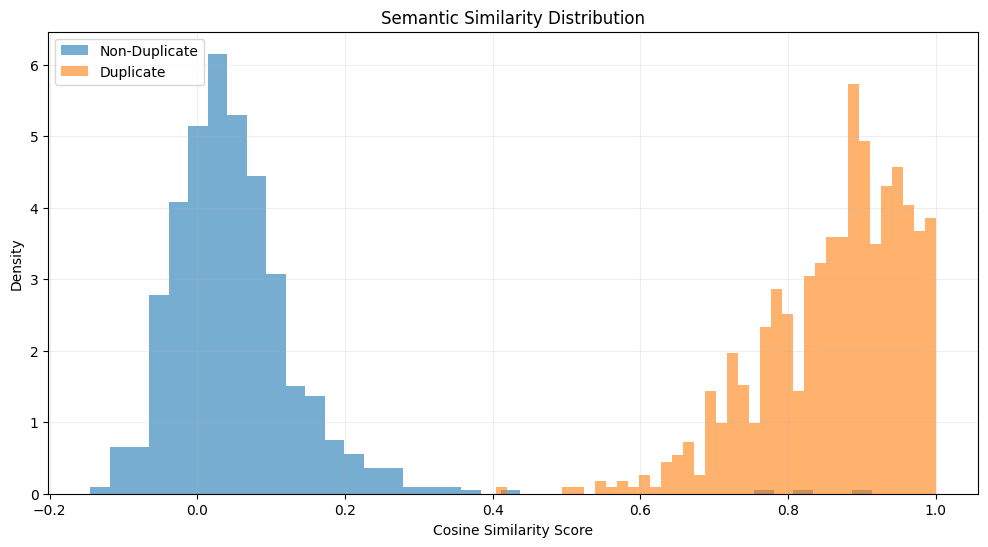

📊 Similarity Statistics

Duplicate pairs:
Mean : 0.8629
Min  : 0.4048
Max  : 1.0

Non-duplicate pairs:
Mean : 0.0495
Min  : -0.1446
Max  : 0.9129


In [ ]:
# ============================================
# STEP 11: Visualize Similarity Distributions
# ============================================

# Create a DataFrame for validation results
val_results = pd.DataFrame({
    "similarity": val_scores,
    "label": val_df["label"].values
})

# Separate the two classes
duplicate_scores = val_results[
    val_results["label"] == 1
]["similarity"]

non_duplicate_scores = val_results[
    val_results["label"] == 0
]["similarity"]


# --------------------------------------------
# Plot the distributions
# --------------------------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    non_duplicate_scores,
    bins=40,
    alpha=0.6,
    label="Non-Duplicate",
    density=True
)

plt.hist(
    duplicate_scores,
    bins=40,
    alpha=0.6,
    label="Duplicate",
    density=True
)

plt.xlabel("Cosine Similarity Score")
plt.ylabel("Density")
plt.title("Semantic Similarity Distribution")
plt.legend()

plt.grid(alpha=0.2)

plt.show()


# --------------------------------------------
# Print statistics
# --------------------------------------------

print("📊 Similarity Statistics")
print("=" * 50)

print("\nDuplicate pairs:")
print("Mean :", round(duplicate_scores.mean(), 4))
print("Min  :", round(duplicate_scores.min(), 4))
print("Max  :", round(duplicate_scores.max(), 4))

print("\nNon-duplicate pairs:")
print("Mean :", round(non_duplicate_scores.mean(), 4))
print("Min  :", round(non_duplicate_scores.min(), 4))
print("Max  :", round(non_duplicate_scores.max(), 4))

In [ ]:
# ============================================
# STEP 12: Optimize Similarity Threshold
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Actual validation labels
y_val = val_df["label"].values

# Store results for every threshold
threshold_results = []

# Test thresholds from 0.40 to 0.95
thresholds = np.arange(0.40, 0.951, 0.01)

for threshold in thresholds:

    # Convert similarity scores into predictions
    y_pred = (
        val_scores >= threshold
    ).astype(int)

    # Calculate evaluation metrics
    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })


# Convert results to DataFrame
threshold_df = pd.DataFrame(threshold_results)


# --------------------------------------------
# Find the best threshold
# --------------------------------------------

best_row = threshold_df.loc[
    threshold_df["f1_score"].idxmax()
]

BEST_THRESHOLD = float(
    best_row["threshold"]
)


print("🎯 Threshold Optimization Completed!")
print("=" * 50)

print(
    f"\nBest Threshold: {BEST_THRESHOLD:.2f}"
)

print(
    f"Validation Accuracy : "
    f"{best_row['accuracy']:.4f}"
)

print(
    f"Validation Precision: "
    f"{best_row['precision']:.4f}"
)

print(
    f"Validation Recall   : "
    f"{best_row['recall']:.4f}"
)

print(
    f"Validation F1 Score : "
    f"{best_row['f1_score']:.4f}"
)

🎯 Threshold Optimization Completed!

Best Threshold: 0.40
Validation Accuracy : 0.9973
Validation Precision: 0.9947
Validation Recall   : 1.0000
Validation F1 Score : 0.9973


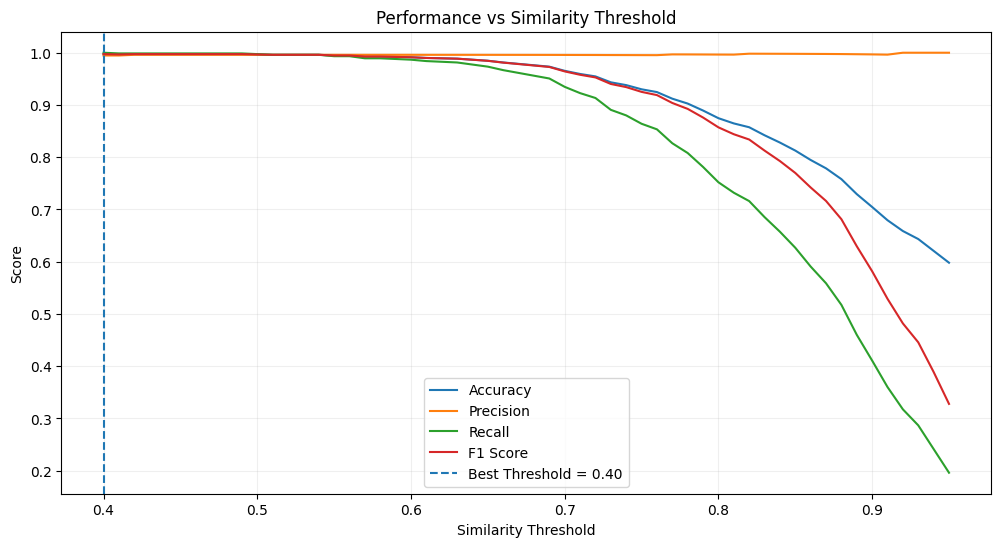

In [ ]:
# ============================================
# STEP 12B: Visualize Threshold Performance
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["accuracy"],
    label="Accuracy"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1_score"],
    label="F1 Score"
)

plt.axvline(
    BEST_THRESHOLD,
    linestyle="--",
    label=f"Best Threshold = {BEST_THRESHOLD:.2f}"
)

plt.xlabel("Similarity Threshold")
plt.ylabel("Score")
plt.title("Performance vs Similarity Threshold")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [ ]:
# ============================================
# STEP 12C: Verify Optimal Threshold
# ============================================

# Test a wider range of thresholds
thresholds_wide = np.arange(0.00, 0.951, 0.01)

verification_results = []

for threshold in thresholds_wide:

    y_pred = (val_scores >= threshold).astype(int)

    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    verification_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

verification_df = pd.DataFrame(verification_results)

# Find the best F1 score
best_f1 = verification_df["f1_score"].max()

best_threshold_rows = verification_df[
    verification_df["f1_score"] == best_f1
]

print("🎯 Threshold Verification")
print("=" * 55)

print(f"\nHighest Validation F1 Score: {best_f1:.4f}")

print("\nThreshold(s) achieving this F1:")
display(best_threshold_rows)

# Show the best few thresholds
print("\nTop 10 threshold configurations:")
display(
    verification_df
    .sort_values("f1_score", ascending=False)
    .head(10)
)

🎯 Threshold Verification

Highest Validation F1 Score: 0.9973

Threshold(s) achieving this F1:


,threshold,accuracy,precision,recall,f1_score
37,0.37,0.997333,0.994695,1.0,0.99734
38,0.38,0.997333,0.994695,1.0,0.99734
39,0.39,0.997333,0.994695,1.0,0.99734
40,0.40,0.997333,0.994695,1.0,0.99734



Top 10 threshold configurations:


,threshold,accuracy,precision,recall,f1_score
40,0.40,0.997333,0.994695,1.000000,0.997340
37,0.37,0.997333,0.994695,1.000000,0.997340
39,0.39,0.997333,0.994695,1.000000,0.997340
38,0.38,0.997333,0.994695,1.000000,0.997340
46,0.46,0.997333,0.996011,0.998667,0.997337
42,0.42,0.997333,0.996011,0.998667,0.997337
43,0.43,0.997333,0.996011,0.998667,0.997337
44,0.44,0.997333,0.996011,0.998667,0.997337
48,0.48,0.997333,0.996011,0.998667,0.997337
49,0.49,0.997333,0.996011,0.998667,0.997337


In [ ]:
# ============================================
# STEP 13: FINAL TEST SET EVALUATION
# ============================================

# Lock the threshold selected from validation
FINAL_THRESHOLD = 0.40

print("🔒 Final threshold locked at:", FINAL_THRESHOLD)

# --------------------------------------------
# Generate predictions on TEST data
# --------------------------------------------

y_test = test_df["label"].values

test_predictions = (
    test_scores >= FINAL_THRESHOLD
).astype(int)


# --------------------------------------------
# Calculate final metrics
# --------------------------------------------

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)


# --------------------------------------------
# Display final results
# --------------------------------------------

print("\n" + "=" * 55)
print("🏆 FINAL TEST SET PERFORMANCE")
print("=" * 55)

print(f"\nAccuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")

print("\nTest samples:", len(y_test))
print("Threshold  :", FINAL_THRESHOLD)

🔒 Final threshold locked at: 0.4

🏆 FINAL TEST SET PERFORMANCE

Accuracy  : 0.9980
Precision : 0.9960
Recall    : 1.0000
F1 Score  : 0.9980

Test samples: 1500
Threshold  : 0.4


Confusion Matrix:
[[747   3]
 [  0 750]]


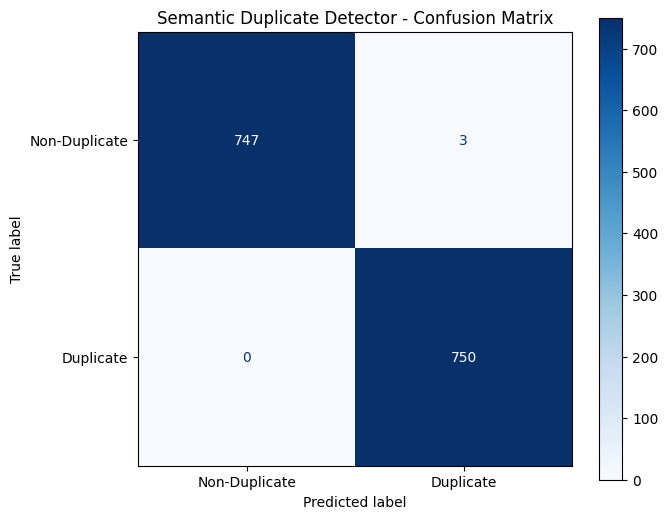

In [ ]:
# ============================================
# STEP 13B: CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    test_predictions
)

print("Confusion Matrix:")
print(cm)


# Display the confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Non-Duplicate",
        "Duplicate"
    ]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title(
    "Semantic Duplicate Detector - Confusion Matrix"
)

plt.show()

In [ ]:
# ============================================
# STEP 14: SEMANTIC DUPLICATE PREDICTION ENGINE
# ============================================

FINAL_THRESHOLD = 0.40


def detect_duplicate(question1, question2):
    """
    Detect whether two questions are semantically duplicate.
    """

    # ----------------------------------------
    # Validate input
    # ----------------------------------------

    if not question1 or not question2:
        return {
            "status": "error",
            "message": "Please enter both questions."
        }

    question1 = str(question1).strip()
    question2 = str(question2).strip()

    if len(question1) == 0 or len(question2) == 0:
        return {
            "status": "error",
            "message": "Please enter both questions."
        }

    # ----------------------------------------
    # Generate embeddings
    # ----------------------------------------

    embeddings = model.encode(
        [question1, question2],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    embedding1 = embeddings[0]
    embedding2 = embeddings[1]

    # ----------------------------------------
    # Calculate cosine similarity
    # ----------------------------------------

    similarity = float(
        np.dot(
            embedding1,
            embedding2
        )
    )

    # Keep score within valid range
    similarity = max(-1.0, min(1.0, similarity))

    # ----------------------------------------
    # Convert to percentage
    # ----------------------------------------

    similarity_percentage = similarity * 100

    # ----------------------------------------
    # Make prediction
    # ----------------------------------------

    is_duplicate = (
        similarity >= FINAL_THRESHOLD
    )

    if is_duplicate:
        prediction = "Duplicate"
        status = "🟢 SEMANTIC DUPLICATE"
        explanation = (
            "The two questions have highly similar "
            "semantic meaning."
        )
    else:
        prediction = "Non-Duplicate"
        status = "🔴 NOT A DUPLICATE"
        explanation = (
            "The two questions have different "
            "semantic meaning."
        )

    # ----------------------------------------
    # Return result
    # ----------------------------------------

    return {
        "status": "success",
        "prediction": prediction,
        "display_status": status,
        "similarity": similarity,
        "similarity_percentage": similarity_percentage,
        "threshold": FINAL_THRESHOLD,
        "explanation": explanation
    }


print("✅ Prediction engine created successfully!")

✅ Prediction engine created successfully!


In [ ]:
# ============================================
# STEP 14B: TEST PREDICTION ENGINE
# ============================================

result = detect_duplicate(
    "How do I reset my password?",
    "I forgot my password. How can I reset it?"
)

print("=" * 55)
print("🤖 SEMANTIC DUPLICATE DETECTOR")
print("=" * 55)

print("\nPrediction :", result["prediction"])

print(
    "Similarity : "
    f"{result['similarity_percentage']:.2f}%"
)

print(
    "Threshold  : "
    f"{result['threshold'] * 100:.0f}%"
)

print("\n", result["display_status"])

print("\nExplanation:")
print(result["explanation"])

🤖 SEMANTIC DUPLICATE DETECTOR

Prediction : Duplicate
Similarity : 93.73%
Threshold  : 40%

 🟢 SEMANTIC DUPLICATE

Explanation:
The two questions have highly similar semantic meaning.


In [ ]:
# ============================================
# STEP 15: CHECK GRADIO VERSION
# ============================================

print("Gradio version:", gr.__version__)
print("✅ Ready to build the UI!")

Gradio version: 6.26.0
✅ Ready to build the UI!


In [1]:
# ============================================================
# STEP 16 — FINAL AI SEMANTIC DUPLICATE DETECTOR UI
# ============================================================
#
# UI REDESIGN NOTE:
# The interface layer below is a green-on-black, compact theme
# with a downloadable report. The detection logic is untouched:
# same embedding model, same normalized encode() calls, same
# util.cos_sim() computation, same FINAL_THRESHOLD (0.40), and
# the same ">= threshold" decision rule. generate_report() runs
# that identical sequence a second time (embed -> cosine ->
# threshold) purely to write the numbers to a text file; it does
# not alter how a pair is classified.
# ============================================================

import os
import tempfile
from datetime import datetime

import gradio as gr
import numpy as np
from sentence_transformers import SentenceTransformer, util

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


# ============================================================
# 1. FINAL MODEL + THRESHOLD
# ============================================================

FINAL_THRESHOLD = 0.40


# ============================================================
# 2. FIND EXISTING SENTENCE TRANSFORMER MODEL
# ============================================================

def get_embedding_model():

    # Check whether a model already exists in the notebook
    possible_names = [
        "embedding_model",
        "sentence_model",
        "semantic_model",
        "model"
    ]

    for name in possible_names:

        if name in globals():

            candidate = globals()[name]

            # SentenceTransformer models have encode()
            if hasattr(candidate, "encode"):

                print(f"✅ Using existing model: {name}")

                return candidate

    # --------------------------------------------------------
    # If no model was found, load a standard model
    # --------------------------------------------------------

    print("⚠️ Existing embedding model not found.")
    print("📥 Loading Sentence Transformer model...")

    new_model = SentenceTransformer(
        "sentence-transformers/all-MiniLM-L6-v2"
    )

    print("✅ Sentence Transformer loaded successfully!")

    return new_model


# Load model once
UI_MODEL = get_embedding_model()


# ============================================================
# 3. PRESENTATION HELPERS (UI packaging only)
# ============================================================

def _status_card(kind, label, desc):
    """kind: 'dup' | 'not_dup' | 'warn'"""
    return f"""
    <div class="status-card status-{kind}">
        <span class="status-dot"></span>
        <div class="status-text">
            <div class="status-label">{label}</div>
            <div class="status-desc">{desc}</div>
        </div>
    </div>
    """


def _meter(similarity_pct, threshold_pct, active=True):
    fill = max(0.0, min(100.0, similarity_pct))
    marker = max(0.0, min(100.0, threshold_pct))
    fill_color = "var(--dup)" if similarity_pct >= threshold_pct else "var(--not-dup)"

    if not active:
        return """
        <div class="meter">
            <div class="meter-track">
                <div class="meter-fill meter-empty" style="width:0%"></div>
            </div>
            <div class="meter-labels">
                <span class="mono">score —</span>
                <span class="mono muted">threshold 40%</span>
            </div>
        </div>
        """

    return f"""
    <div class="meter">
        <div class="meter-track">
            <div class="meter-fill" style="width:{fill}%; background:{fill_color}"></div>
            <div class="meter-threshold" style="left:{marker}%" title="Decision threshold"></div>
        </div>
        <div class="meter-labels">
            <span class="mono">score {similarity_pct:.2f}%</span>
            <span class="mono muted">threshold {threshold_pct:.0f}%</span>
        </div>
    </div>
    """


def _build_chart(history):
    """Bar chart of similarity scores across the session's comparisons,
    with the decision threshold drawn as a reference line. Purely a
    visualization of numbers already produced elsewhere — it does not
    compute or alter any classification itself."""

    fig, ax = plt.subplots(figsize=(9, 3), dpi=110)
    fig.patch.set_facecolor("#121510")
    ax.set_facecolor("#121510")

    if not history:

        ax.text(
            0.5, 0.5, "Run an analysis to see it charted here",
            ha="center", va="center", color="#8CA391", fontsize=11,
            transform=ax.transAxes
        )
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_color("#262B21")

        fig.tight_layout()
        return fig

    xs = list(range(1, len(history) + 1))
    scores = [h["similarity"] for h in history]

    palette = ["#34D399", "#38BDF8", "#FBBF24", "#A78BFA", "#F472B6", "#FB923C", "#2DD4BF", "#F87171"]
    colors = [palette[i % len(palette)] for i in range(len(history))]

    threshold_pct = FINAL_THRESHOLD * 100

    ax.bar(xs, scores, color=colors, width=0.55, zorder=3)
    ax.axhline(threshold_pct, color="#F4FBF5", linestyle="--", linewidth=1, alpha=0.6, zorder=2)
    ax.text(
        len(xs) + 0.55, threshold_pct, f" threshold {threshold_pct:.0f}%",
        color="#F4FBF5", fontsize=9, va="center", alpha=0.75
    )

    ax.set_xlim(0.3, len(xs) + 2.2)
    ax.set_ylim(0, 100)
    ax.set_xticks(xs)
    ax.set_xticklabels([f"#{i}" for i in xs], color="#8CA391", fontsize=9)
    ax.set_ylabel("Similarity %", color="#8CA391", fontsize=9)
    ax.tick_params(colors="#8CA391", length=0)
    ax.grid(axis="y", color="#262B21", linewidth=0.6, zorder=0)

    for spine in ax.spines.values():
        spine.set_color("#262B21")

    ax.set_title("Similarity across this session's comparisons", color="#E9F3E9", fontsize=11, loc="left")

    fig.tight_layout()
    return fig


# ============================================================
# 4. SEMANTIC DUPLICATE FUNCTION  (core logic unchanged)
# ============================================================

def analyze_questions(question1, question2):

    # --------------------------------------------------------
    # Validate input
    # --------------------------------------------------------

    if question1 is None:
        question1 = ""

    if question2 is None:
        question2 = ""

    question1 = question1.strip()
    question2 = question2.strip()

    if question1 == "" or question2 == "":

        return (
            _status_card("warn", "Input required", "Enter both questions to run a comparison."),
            _meter(0, FINAL_THRESHOLD * 100, active=False),
            "Enter two questions above, then click Analyze."
        )

    # --------------------------------------------------------
    # Generate embeddings
    # --------------------------------------------------------

    try:

        embedding1 = UI_MODEL.encode(
            question1,
            convert_to_tensor=True,
            normalize_embeddings=True
        )

        embedding2 = UI_MODEL.encode(
            question2,
            convert_to_tensor=True,
            normalize_embeddings=True
        )

    except Exception as e:

        return (
            _status_card("warn", "Model error", "Unable to generate embeddings."),
            _meter(0, FINAL_THRESHOLD * 100, active=False),
            f"Model error: {str(e)}"
        )

    # --------------------------------------------------------
    # Cosine similarity
    # --------------------------------------------------------

    try:

        similarity = float(
            util.cos_sim(
                embedding1,
                embedding2
            ).item()
        )

    except Exception as e:

        return (
            _status_card("warn", "Similarity error", "Unable to calculate similarity."),
            _meter(0, FINAL_THRESHOLD * 100, active=False),
            f"Similarity calculation error: {str(e)}"
        )

    # --------------------------------------------------------
    # Classification using validated threshold
    # --------------------------------------------------------

    similarity_pct = similarity * 100
    threshold_pct = FINAL_THRESHOLD * 100

    if similarity >= FINAL_THRESHOLD:

        status_html = _status_card(
            "dup",
            "Semantic duplicate",
            "These questions carry highly similar meaning."
        )

        explanation = (
            f"Similarity came out to {similarity_pct:.2f}%, which is at or above "
            f"the {threshold_pct:.0f}% decision threshold — so the pair is "
            f"classified as a semantic duplicate."
        )

    else:

        status_html = _status_card(
            "not_dup",
            "Not a duplicate",
            "These questions carry different meaning."
        )

        explanation = (
            f"Similarity came out to {similarity_pct:.2f}%, which is below "
            f"the {threshold_pct:.0f}% decision threshold — so the pair is "
            f"classified as non-duplicate."
        )

    meter_html = _meter(similarity_pct, threshold_pct, active=True)

    return (status_html, meter_html, explanation)


# ============================================================
# 4b. CHART WRAPPER (new — calls analyze_questions() above
#     completely unchanged, then separately re-derives just the
#     numeric similarity to log a point on the history chart)
# ============================================================

def analyze_and_chart(question1, question2, history):

    status_html, meter_html, explanation = analyze_questions(question1, question2)

    if history is None:
        history = []

    q1 = (question1 or "").strip()
    q2 = (question2 or "").strip()

    if q1 != "" and q2 != "":

        try:
            embedding1 = UI_MODEL.encode(q1, convert_to_tensor=True, normalize_embeddings=True)
            embedding2 = UI_MODEL.encode(q2, convert_to_tensor=True, normalize_embeddings=True)
            similarity = float(util.cos_sim(embedding1, embedding2).item())

            history = history + [{
                "similarity": similarity * 100,
                "dup": similarity >= FINAL_THRESHOLD
            }]

        except Exception:
            pass  # status_html above already reports the error; chart just skips this point

    chart = _build_chart(history)

    return status_html, meter_html, explanation, chart, history


# ============================================================
# 5. CLEAR FUNCTION
# ============================================================

def clear_all():

    return (
        "",
        "",
        _status_card("warn", "Ready", "Enter two questions to compare their semantic meaning."),
        _meter(0, FINAL_THRESHOLD * 100, active=False),
        "",
        None,
        _build_chart([]),
        []
    )


# ============================================================
# 6. REPORT GENERATION (new — reuses the same detection steps
#    purely to write them to a downloadable text file)
# ============================================================

def generate_report(question1, question2):

    q1 = (question1 or "").strip()
    q2 = (question2 or "").strip()

    if q1 == "" or q2 == "":
        raise gr.Error("Enter both questions before downloading a report.")

    try:
        embedding1 = UI_MODEL.encode(q1, convert_to_tensor=True, normalize_embeddings=True)
        embedding2 = UI_MODEL.encode(q2, convert_to_tensor=True, normalize_embeddings=True)
        similarity = float(util.cos_sim(embedding1, embedding2).item())
    except Exception as e:
        raise gr.Error(f"Could not generate report: {str(e)}")

    similarity_pct = similarity * 100
    threshold_pct = FINAL_THRESHOLD * 100
    verdict = "SEMANTIC DUPLICATE" if similarity >= FINAL_THRESHOLD else "NOT A DUPLICATE"

    report_text = "\n".join([
        "SEMANTIC DUPLICATE DETECTION REPORT",
        "=" * 42,
        f"Generated : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
        "",
        f"Question A : {q1}",
        f"Question B : {q2}",
        "",
        f"Similarity Score  : {similarity_pct:.2f}%",
        f"Decision Threshold: {threshold_pct:.0f}%",
        f"Verdict           : {verdict}",
        "",
        "Method: cosine similarity on normalized sentence-transformer embeddings.",
    ])

    report_path = os.path.join(tempfile.gettempdir(), "semantic_duplicate_report.txt")

    with open(report_path, "w", encoding="utf-8") as f:
        f.write(report_text)

    return report_path


# ============================================================
# 7. CUSTOM CSS — green on black, compact
# ============================================================

custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Manrope:wght@500;700;800&family=Inter:wght@400;500;600&family=IBM+Plex+Mono:wght@500;600&display=swap');

:root {
    --bg: #0A0C0A;
    --surface: #121510;
    --surface-2: #171B14;
    --border: #262B21;
    --ink: #E9F3E9;
    --muted: #8CA391;
    --green: #22C55E;
    --green-dark: #16A34A;
    --green-soft: rgba(34,197,94,0.12);
    --dup: #34D399;
    --dup-bg: rgba(52,211,153,0.10);
    --dup-border: rgba(52,211,153,0.35);
    --not-dup: #F87171;
    --not-dup-bg: rgba(248,113,113,0.10);
    --not-dup-border: rgba(248,113,113,0.35);
    --warn: #FBBF24;
    --warn-bg: rgba(251,191,36,0.10);
    --warn-border: rgba(251,191,36,0.35);
}

html, body {
    background: var(--bg) !important;
    margin: 0 !important;
    padding: 0 !important;
}

.gradio-container {
    max-width: 100% !important;
    width: 100% !important;
    margin: 0 !important;
    padding: 16px 5vw !important;
    box-sizing: border-box !important;
    background: var(--bg) !important;
    font-family: 'Inter', sans-serif !important;
    color: var(--ink) !important;
}

.mono { font-family: 'IBM Plex Mono', monospace; font-size: 12.5px; }
.muted { color: var(--muted); }

footer { display: none !important; }

/* ---------------- Hero ---------------- */

.hero {
    position: relative;
    padding: 18px 20px;
    border-radius: 12px;
    background:
        radial-gradient(circle, rgba(34,197,94,0.20) 1px, transparent 1.4px) 0 0 / 18px 18px,
        var(--surface);
    border: 1px solid var(--border);
    overflow: hidden;
}

.hero-mark {
    display: flex;
    align-items: center;
    gap: 8px;
    margin-bottom: 6px;
}

.hero-mark svg { display: block; }

.hero-eyebrow {
    font-family: 'IBM Plex Mono', monospace;
    font-size: 12px;
    color: var(--green);
}

.hero-title {
    font-family: 'Manrope', sans-serif;
    font-weight: 800;
    font-size: 26px;
    line-height: 1.1;
    margin: 0 0 4px 0;
    color: #F4FBF5;
}

.hero-sub {
    font-size: 13.5px;
    color: var(--muted);
    max-width: 520px;
    line-height: 1.4;
}

/* ---------------- Section headings ---------------- */

.section-heading {
    font-family: 'Manrope', sans-serif;
    font-weight: 700;
    font-size: 16px;
    color: #F4FBF5;
    margin: 14px 0 8px 0;
}

/* ---------------- Inputs ---------------- */

.input-card textarea, .input-card label span {
    font-family: 'Inter', sans-serif !important;
}

.input-card label span { color: var(--muted) !important; }

.input-card textarea {
    border-radius: 8px !important;
    border: 1px solid var(--border) !important;
    background: var(--surface-2) !important;
    color: var(--ink) !important;
}

.input-card textarea:focus {
    border-color: var(--green) !important;
    box-shadow: 0 0 0 3px var(--green-soft) !important;
}

.input-card { background: transparent !important; border: none !important; }

/* ---------------- Buttons ---------------- */

.analyze-btn {
    font-family: 'Inter', sans-serif !important;
    font-size: 14px !important;
    font-weight: 700 !important;
    border-radius: 8px !important;
    background: var(--green) !important;
    border: none !important;
    color: #06170D !important;
    box-shadow: none !important;
}

.analyze-btn:hover { background: var(--green-dark) !important; }

.clear-btn, .download-btn {
    font-family: 'Inter', sans-serif !important;
    font-size: 14px !important;
    font-weight: 600 !important;
    border-radius: 8px !important;
    background: var(--surface-2) !important;
    border: 1px solid var(--border) !important;
    color: var(--ink) !important;
}

.clear-btn:hover, .download-btn:hover {
    border-color: var(--green) !important;
    color: var(--green) !important;
}

/* ---------------- Result panel ---------------- */

.result-panel {
    border: 1px solid var(--border) !important;
    border-radius: 12px !important;
    background: var(--surface) !important;
    padding: 14px 16px !important;
}

@keyframes revealIn {
    from { opacity: 0; transform: translateY(3px); }
    to { opacity: 1; transform: translateY(0); }
}

.status-card {
    display: flex;
    align-items: flex-start;
    gap: 10px;
    padding: 10px 12px;
    border-radius: 8px;
    border: 1px solid var(--border);
    background: var(--surface-2);
    animation: revealIn 0.3s ease;
}

.status-dot {
    width: 9px;
    height: 9px;
    border-radius: 50%;
    margin-top: 5px;
    flex-shrink: 0;
    background: var(--muted);
}

.status-label {
    font-family: 'Manrope', sans-serif;
    font-weight: 700;
    font-size: 14.5px;
    color: var(--ink);
}

.status-desc {
    font-size: 13px;
    color: var(--muted);
    margin-top: 1px;
}

.status-dup { background: var(--dup-bg); border-color: var(--dup-border); }
.status-dup .status-dot { background: var(--dup); }
.status-dup .status-label { color: var(--dup); }

.status-not_dup { background: var(--not-dup-bg); border-color: var(--not-dup-border); }
.status-not_dup .status-dot { background: var(--not-dup); }
.status-not_dup .status-label { color: var(--not-dup); }

.status-warn { background: var(--warn-bg); border-color: var(--warn-border); }
.status-warn .status-dot { background: var(--warn); }
.status-warn .status-label { color: var(--warn); }

/* ---------------- Similarity meter ---------------- */

.meter { margin-top: 10px; animation: revealIn 0.4s ease; }

.meter-track {
    position: relative;
    width: 100%;
    height: 8px;
    background: var(--border);
    border-radius: 5px;
    overflow: visible;
}

.meter-fill {
    height: 100%;
    border-radius: 5px;
    transition: width 0.5s ease;
}

.meter-empty { background: transparent; }

.meter-threshold {
    position: absolute;
    top: -3px;
    width: 2px;
    height: 14px;
    background: #F4FBF5;
    opacity: 0.6;
}

.meter-labels {
    display: flex;
    justify-content: space-between;
    margin-top: 6px;
}

/* ---------------- Chart ---------------- */

.chart-card {
    background: var(--surface) !important;
    border: 1px solid var(--border) !important;
    border-radius: 10px !important;
    padding: 4px !important;
}

.chart-card > div {
    background: transparent !important;
}

/* ---------------- Explanation ---------------- */

.explanation-card label span { color: var(--muted) !important; }

.explanation-card textarea {
    border-radius: 8px !important;
    border: 1px solid var(--border) !important;
    background: var(--surface-2) !important;
    color: var(--ink) !important;
    font-size: 13.5px !important;
}

/* ---------------- Examples ---------------- */

.gradio-container .table-wrap,
.gradio-container table,
.gradio-container thead,
.gradio-container tbody,
.gradio-container tr,
.gradio-container th,
.gradio-container td {
    background: var(--surface) !important;
    border-color: var(--border) !important;
    color: var(--ink) !important;
}

.gradio-container th {
    color: var(--green) !important;
    font-weight: 700 !important;
}

.gradio-container tbody tr:nth-child(even) td {
    background: var(--surface-2) !important;
}

.gradio-container tbody tr:hover td {
    background: var(--green-soft) !important;
    color: #F4FBF5 !important;
}

.gradio-container .label-wrap,
.gradio-container .label-wrap span {
    color: var(--muted) !important;
}

/* ---------------- Footer ---------------- */

.app-footer {
    text-align: center;
    color: var(--muted);
    padding: 10px 0 2px 0;
    font-size: 12px;
    border-top: 1px solid var(--border);
    margin-top: 16px;
}

/* ---------------- Tighten overall layout ---------------- */

.gradio-container .form,
.gradio-container .block {
    background: transparent;
}

.gradio-container .row {
    gap: 10px !important;
}

/* ---------------- Responsive ---------------- */

@media (max-width: 640px) {
    .hero-title { font-size: 21px; }
    .gradio-container { margin: 8px auto !important; }
}
"""


# ============================================================
# 8. BUILD GRADIO APPLICATION
# ============================================================

with gr.Blocks(
    title="Semantic Duplicate Detector",
    css=custom_css,
    theme=gr.themes.Base(
        primary_hue="green",
        neutral_hue="gray",
        font=["Inter", "sans-serif"],
        spacing_size="sm",
        radius_size="sm"
    )
) as demo:

    # ========================================================
    # HEADER
    # ========================================================

    gr.HTML(
        """
        <div class="hero">
            <div class="hero-mark">
                <svg width="22" height="22" viewBox="0 0 26 26" fill="none">
                    <circle cx="5" cy="8" r="3" fill="#22C55E"/>
                    <circle cx="21" cy="5" r="3" fill="#22C55E" opacity="0.55"/>
                    <circle cx="19" cy="21" r="3" fill="#22C55E" opacity="0.8"/>
                    <line x1="5" y1="8" x2="21" y2="5" stroke="#22C55E" stroke-width="1.2" opacity="0.4"/>
                    <line x1="5" y1="8" x2="19" y2="21" stroke="#22C55E" stroke-width="1.2" opacity="0.4"/>
                </svg>
                <span class="hero-eyebrow">embedding similarity</span>
            </div>
            <div class="hero-title">Semantic Duplicate Detector</div>
            <div class="hero-sub">
                Encode two questions into vector space and measure how close their meaning sits,
                using cosine similarity against a validated decision threshold.
            </div>
        </div>
        """
    )

    # ========================================================
    # INPUT SECTION
    # ========================================================

    gr.HTML('<div class="section-heading">Compare two questions</div>')

    with gr.Row():

        with gr.Column():

            question1 = gr.Textbox(
                label="Question A",
                placeholder="Example: How do I reset my password?",
                lines=4,
                elem_classes="input-card"
            )

        with gr.Column():

            question2 = gr.Textbox(
                label="Question B",
                placeholder="Example: I forgot my password. How can I reset it?",
                lines=4,
                elem_classes="input-card"
            )

    with gr.Row():

        analyze_button = gr.Button(
            "Analyze similarity",
            variant="primary",
            elem_classes="analyze-btn"
        )

        clear_button = gr.Button(
            "Clear",
            variant="secondary",
            elem_classes="clear-btn"
        )

        download_button = gr.DownloadButton(
            "Download report",
            elem_classes="download-btn"
        )

    # ========================================================
    # RESULTS
    # ========================================================

    gr.HTML('<div class="section-heading">Result</div>')

    history_state = gr.State([])

    with gr.Column(elem_classes="result-panel"):

        status_output = gr.HTML(
            _status_card("warn", "Ready", "Enter two questions to compare their semantic meaning.")
        )

        meter_output = gr.HTML(
            _meter(0, FINAL_THRESHOLD * 100, active=False)
        )

        explanation_output = gr.Textbox(
            label="Explanation",
            lines=2,
            interactive=False,
            elem_classes="explanation-card"
        )

    gr.HTML('<div class="section-heading">Session summary</div>')

    chart_output = gr.Plot(
        value=_build_chart([]),
        elem_classes="chart-card result-panel"
    )

    # ========================================================
    # EXAMPLES
    # ========================================================

    gr.HTML('<div class="section-heading">Try example pairs</div>')

    gr.Examples(

        examples=[

            [
                "How do I reset my password?",
                "I forgot my password. How can I reset it?"
            ],

            [
                "How can I learn Python?",
                "What is the best way to start learning Python?"
            ],

            [
                "How do I contact someone on Quora?",
                "How can I message someone on Quora?"
            ],

            [
                "What is the capital of India?",
                "How do I make chocolate cake?"
            ],

            [
                "How can I improve my programming skills?",
                "What are the best ways to become better at coding?"
            ]

        ],

        inputs=[
            question1,
            question2
        ]

    )

    # ========================================================
    # FOOTER
    # ========================================================

    gr.HTML(
        """
        <div class="app-footer">
            Sentence Transformers · Cosine Similarity · Quora Question Pairs
        </div>
        """
    )

    # ========================================================
    # ANALYZE BUTTON EVENT
    # ========================================================

    analyze_button.click(

        fn=analyze_and_chart,

        inputs=[
            question1,
            question2,
            history_state
        ],

        outputs=[
            status_output,
            meter_output,
            explanation_output,
            chart_output,
            history_state
        ]

    )

    # ========================================================
    # CLEAR BUTTON EVENT
    # ========================================================

    clear_button.click(

        fn=clear_all,

        inputs=[],

        outputs=[
            question1,
            question2,
            status_output,
            meter_output,
            explanation_output,
            download_button,
            chart_output,
            history_state
        ]

    )

    # ========================================================
    # DOWNLOAD REPORT BUTTON EVENT
    # ========================================================

    download_button.click(

        fn=generate_report,

        inputs=[
            question1,
            question2
        ],

        outputs=[
            download_button
        ]

    )


# ============================================================
# 9. LAUNCH APPLICATION
# ============================================================

print("=" * 60)
print("🚀 AI SEMANTIC DUPLICATE DETECTOR")
print("=" * 60)
print(f"Decision Threshold : {FINAL_THRESHOLD}")
print("Model              : Ready")
print("UI                 : Ready")
print("=" * 60)

demo.launch(
    share=True
)

⚠️ Existing embedding model not found.
📥 Loading Sentence Transformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Sentence Transformer loaded successfully!


/tmp/ipykernel_1848/38235349.py:749: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


🚀 AI SEMANTIC DUPLICATE DETECTOR
Decision Threshold : 0.4
Model              : Ready
UI                 : Ready
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f34499ea0022bbd244.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
